## Welcome to the Solar wind High-speed Enhancements And Transients Handler (SHEATH)
SHEATH is a CNN which ingests images and magnetograms of the Sun near the Central Meridian.
It predicts various solar wind parameters far downstream (currently OMNI, but can be changed to predict at L1).
These solar wind parameters can be fed into DAGGER to generate ground magnetic perturbations with greater uncertainty but also an order of magnitude more lead time.

In [1]:
# Imports
from train_SHEATH import *

# Well that was easy

In [2]:
# Loading the placeholder for ARD's ARD (which is just our train/test set for now)
in_dataset = np.asarray(
    [np.load(v) for v in sorted(glob(f"{DATAPATH}masked*.npy"))]
).transpose([1, 2, 3, 0])
print("Samples, Image Height, Cropped Image Width, Channels")
in_dataset.shape

Samples, Image Height, Cropped Image Width, Channels


(6135, 512, 34, 12)

In [3]:
# Order of input channels
sorted(glob(f"{DATAPATH}masked*.npy"))

['sheath_data/masked_131A.npy',
 'sheath_data/masked_1600A.npy',
 'sheath_data/masked_1700A.npy',
 'sheath_data/masked_171A.npy',
 'sheath_data/masked_193A.npy',
 'sheath_data/masked_211A.npy',
 'sheath_data/masked_304A.npy',
 'sheath_data/masked_335A.npy',
 'sheath_data/masked_94A.npy',
 'sheath_data/masked_Bx.npy',
 'sheath_data/masked_By.npy',
 'sheath_data/masked_Bz.npy']

In [4]:
# The target features
out_feature_names = [
    "Field magnitude average, nT",
    "BX, nT (GSE, GSM)",
    "BY, nT (GSM)",
    "BZ, nT (GSM)",
    "Speed, km/s",
    "Proton Density, n/cc",
    "Proton Temperature, K",
]
print(out_feature_names)

# Backtrace solar wind test datapoints to their parent SDO images
timestamps_sun = np.load(f"{DATAPATH}timestamps.npy", allow_pickle=True)
omni_data = pd.read_hdf(f"{DATAPATH}omni_preprocess.h5", key="omni")
omni_data["Proton Temperature, K"] = np.log10(omni_data["Proton Temperature, K"])
omni_data = omni_data.dropna(axis="rows")
aia_dates_omni = get_backtrace_date(omni_data.values[:, 5], omni_data.values[:, 0])
omni_data = omni_data[["Date"] + out_feature_names]
output_data = omni_data.values[:, 1:]
# Select OMNI data closest to SDO data
aia_nearest_inds = np.argmin(
    np.abs(aia_dates_omni[:, None] - timestamps_sun[None, :]), axis=1
)
input_data = in_dataset[aia_nearest_inds]
input_timestamps = timestamps_sun[aia_nearest_inds]

['Field magnitude average, nT', 'BX, nT (GSE, GSM)', 'BY, nT (GSM)', 'BZ, nT (GSM)', 'Speed, km/s', 'Proton Density, n/cc', 'Proton Temperature, K']


/home/jupyter/2023-FDL-X-GEO/2020-FDL-X-Geo/sheath/train_SHEATH.py:40: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  return (sw_date-pd.to_timedelta(time,unit='day')).to_numpy()


In [5]:
scaler_y = load(open("logs/scaler_y.scaler", "rb"))
target_data = scaler_y.fit_transform(output_data)

# Input scaling
scaler_X = load(open("logs/scaler_X.scaler", "rb"))
input_data = scaler_X.fit_transform(
    input_data.reshape(-1, input_data.shape[-1])
).reshape(input_data.shape)

In [6]:
# Cut down our test dataset
end_timestep = 1000
input_data = in_dataset[:end_timestep, ...]
target_data = target_data[:end_timestep, ...]
input_data.shape, target_data.shape

((1000, 512, 34, 12), (1000, 7))

In [7]:
# Dataloader stuff
test_set = Data(input_data, target_data)
test_loader = data.DataLoader(test_set, batch_size=1, shuffle=False)

In [8]:
HSE_model = HSENN(
    height=in_dataset.shape[1],
    width=in_dataset.shape[2],
    n_passbands=in_dataset.shape[3],
    n_out=len(out_feature_names),
)
if torch.cuda.is_available():
    HSE_model.cuda()
HSE_model.load_state_dict(torch.load("logs/SHEATH.ckpt"))

HSE_model.eval()

HSENN(
  (model): Sequential(
    (0): Conv2d(12, 13, kernel_size=(13, 3), stride=(1, 1), dilation=(3, 3))
    (1): MaxPool2d(kernel_size=(3, 1), stride=(3, 1), padding=0, dilation=1, ceil_mode=False)
    (2): ELU(alpha=1.0)
    (3): Conv2d(13, 15, kernel_size=(9, 3), stride=(1, 1))
    (4): MaxPool2d(kernel_size=(3, 1), stride=(3, 1), padding=0, dilation=1, ceil_mode=False)
    (5): ELU(alpha=1.0)
    (6): Conv2d(15, 17, kernel_size=(7, 1), stride=(1, 1))
    (7): MaxPool2d(kernel_size=(3, 1), stride=(3, 1), padding=0, dilation=1, ceil_mode=False)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (linear): Sequential(
    (0): Linear(in_features=6188, out_features=9, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=9, out_features=7, bias=True)
    (4): ReLU()
  )
)

In [9]:
# Let's forecast some timeseries!
predicted_outputs = []
with torch.no_grad():
    for datum in tqdm(test_loader, desc="Predicting"):
        inputs, outputs = datum
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        inputs, outputs = inputs.to(device), outputs.to(
            device
        )  # outputs = outputs.to(torch.float64)
        this_predicted_outputs = HSE_model(inputs)
        predicted_outputs.append(this_predicted_outputs)
predicted_outputs = torch.cat(predicted_outputs)
predicted_outputs.shape

Predicting: 100%|██████████| 1000/1000 [00:01<00:00, 508.99it/s]


torch.Size([1000, 7])

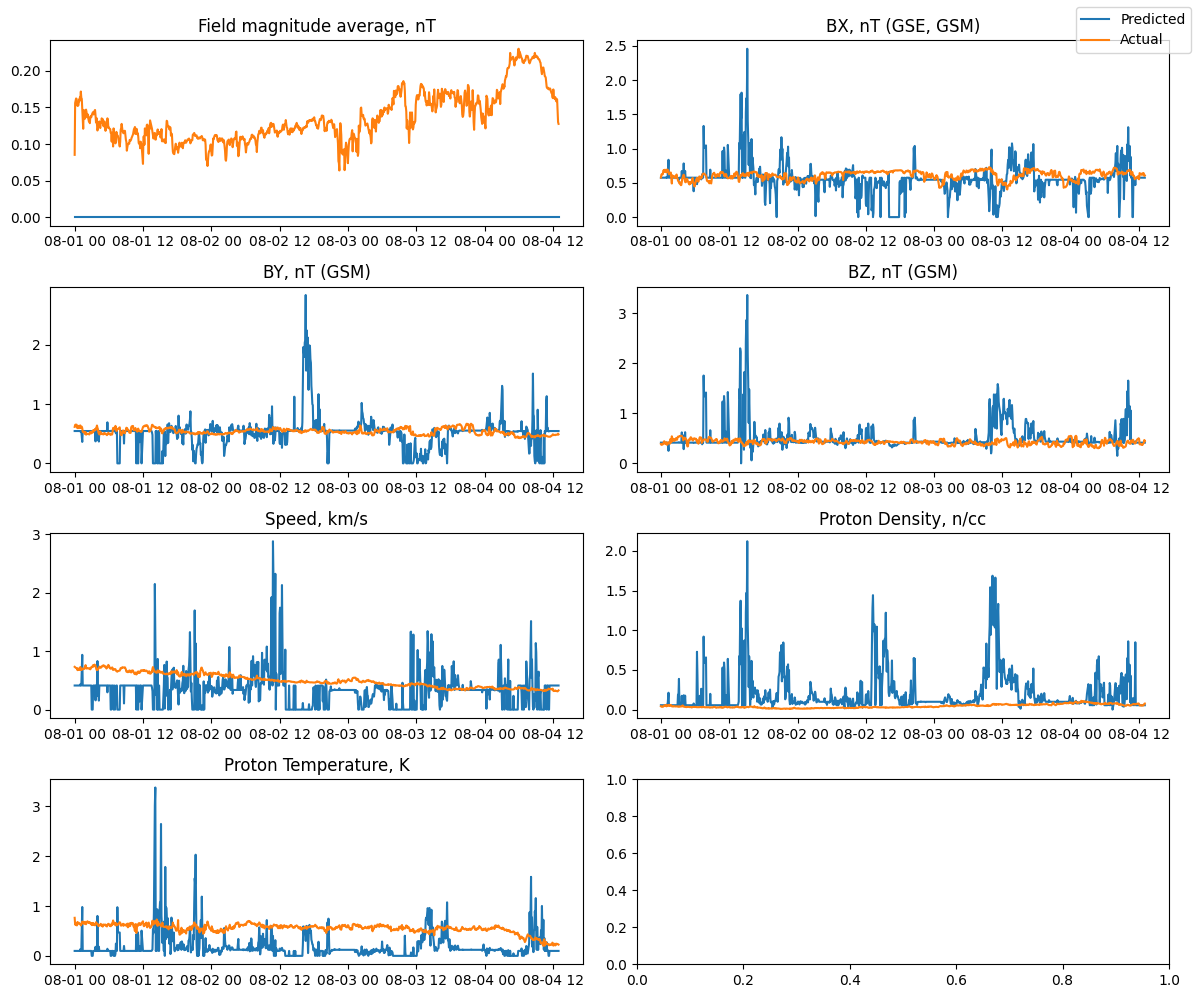

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes = axes.ravel()
predicted_outputs = predicted_outputs.cpu()
# predicted_outputs = scaler_y.inverse_transform(predicted_outputs)
for ai in range(len(out_feature_names)):
    axes[ai].plot(
        omni_data["Date"].iloc[:end_timestep],
        predicted_outputs[:, ai],
        label="Predicted" * (not ai),
    )
    axes[ai].plot(
        omni_data["Date"].iloc[:end_timestep],
        target_data[:, ai],
        label="Actual" * (not ai),
    )
    axes[ai].set_title(out_feature_names[ai])
plt.tight_layout()
fig.legend()
plt.savefig("test_timeseries.png")